In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
# import the libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings(action="ignore")

In [3]:
# set the theme 
sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams["figure.figsize"]=(10,6)

In [4]:
# data Load 
fake=pd.read_csv("../dataset/Fake.csv")
real=pd.read_csv("../dataset/True.csv")

In [5]:
# data shape
print(f"Fake news shape :" ,fake.shape)
print(f"Real news sahpe : ",real.shape)

Fake news shape : (23481, 4)
Real news sahpe :  (21417, 4)


In [6]:
# columns in the data
print("Fake columns :"  ,fake.columns.tolist())
print("Real  columns :"  ,real.columns.tolist())

Fake columns : ['title', 'text', 'subject', 'date']
Real  columns : ['title', 'text', 'subject', 'date']


In [7]:
# sample of data
print("\nFake news sample")
fake.head(3)


Fake news sample


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [8]:
# Means of the columns 
# title : All Article 
# subject -> Cataoegry (politics,news,etc)
#date --> when it is published
# Our model 
# Title + Text -> Fake or real predict 

In [9]:
# Combine the both data 
fake["label"]=0 # 0 =Fake 
real["label"]=1 # 1= Real

In [10]:
df=pd.concat([fake,real],ignore_index=True)
print("Combined shape : ",df.shape)
print("\nLabel distribution")
print(df["label"].value_counts())

Combined shape :  (44898, 5)

Label distribution
label
0    23481
1    21417
Name: count, dtype: int64


In [11]:
# Fake and real are almost same so no problem of imbalance dataset 

In [12]:
# Title-> Text combine -> One columns 
#  i combine both because if i combine them both they will give me more information
# example we all predict that this new is fake or not by reading  it whole.
df["content"]=df["title"]+" "+df["text"]

print("Content column sample: ")
print(df["content"][0][:200]) # first 200 charaacter
print("/nContent length status:")
print(df["content"].str.len().describe())

Content column sample: 
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out
/nContent length status:
count    44898.000000
mean      2550.221413
std       2172.578772
min         31.000000
25%       1318.000000
50%       2270.000000
75%       3189.000000
max      51893.000000
Name: content, dtype: float64


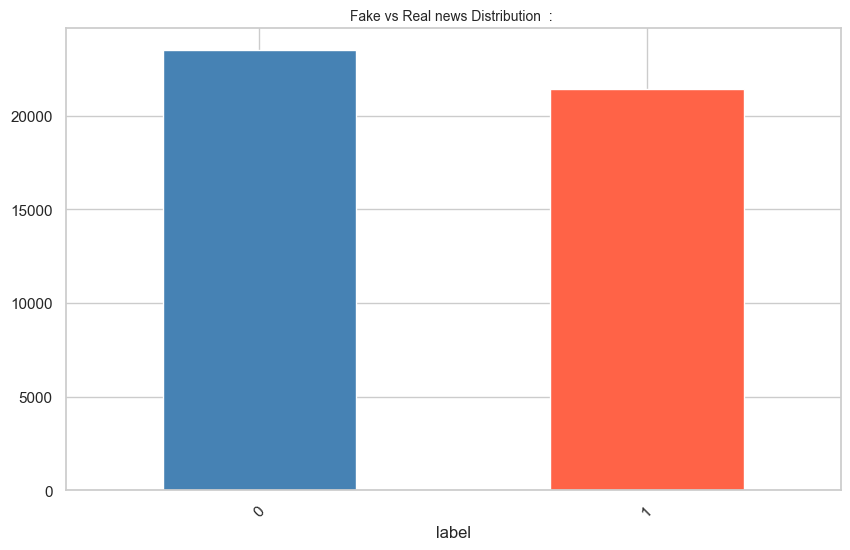

In [13]:
# Label Distribution
plt.figure(figsize=(10,6))
df["label"].value_counts().plot(kind="bar",color=["steelblue","tomato"])
plt.title("Fake vs Real news Distribution  : ",fontsize=(10))
plt.xticks(rotation=45)
plt.show()

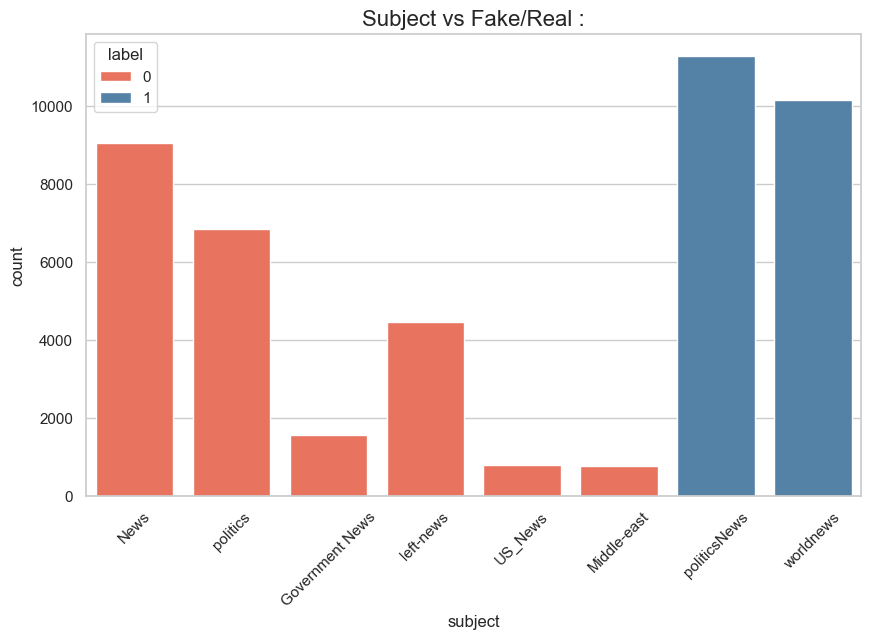

In [14]:
#subject distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="subject",hue="label",palette=["tomato","steelblue"])
plt.title("Subject vs Fake/Real :",fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [15]:
# Insight --> Real news  in the proper categories 
# Fakse news are in Vogue categories

In [16]:
## Count the null value in the data 
print("Missing Value ")
print(df.isnull().sum())

print("\nDuplicate Rows : ")
print(df.duplicated().sum())

print("\nContent length by label :")
df.groupby("label")["content"].apply(lambda x : x.str.len().mean()).round(0)

Missing Value 
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

Duplicate Rows : 
209

Content length by label :


label
0    2643.0
1    2449.0
Name: content, dtype: float64

In [17]:
# Insight -> Fake news is bit long 

In [18]:
# Duplicate remove
print("Before Shape :",df.shape)
df=df.drop_duplicates()
print("After the shape :" ,df.shape)
print("How much Removes",209)

Before Shape : (44898, 6)
After the shape : (44689, 6)
How much Removes 209


In [19]:
# Text Cleaning 
import re 
#regular expression 
# Patterns find Out Tool 
# Example "find the text which is gona starting with http"
import string 
# it is built in the python 
# string.punctuatuion =!A#$
# list of special chracter 
def clean_text(text):
    #Lower Case the text 
    text =text.lower()

    # remove the urls 
    #re.sub(pattern,replacement,text)
    text=re.sub(r'http\S+|www\S+','',text)
    # re.sub -> find out and replace 
    #"http\S+ --> text starting with the https "
    #\S+= koi bhi  chracter till the --> space
    # why i do this -> because the model does not learn any thing from the texts.

    # Punctuation remove 
    text=text.translate(str.maketrans('','',string.punctuation))
    #string punctuation -> "!#&$()"*)
    # maketrans= translation table make
    # why i do this -> fake and fake! are both the same 

    # Extra spaces 
    text=re.sub(r'\s+',' ',text).strip()

    return text 

# apply 
df["content_clean"]=df["content"].apply(clean_text)
print(df["content"][0][:200])
print("\nAfter cleaninh")
print(df["content_clean"][0][:200])

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out

After cleaninh
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to 


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
#working
# make the vocabolary  unique words
# each content vector  by using the vocabalry
# wights -> coomon weight -> weight reduce 
# Unique words -> weight ++
# tf (term frequency)= total words count(particular)/total words in article
# idf(inverse document frequencey )=log(total articals/Article with this word) -> uniquness
# tf_idf=tf*idf

tfidf=TfidfVectorizer(max_features=10000,#top 10000 words 
                      stop_words="english",# common words remove 
                      # "example"-> "the ,is ,at,which"-> remove  because this words cant descide real or fake
                      ngram_range=(1,2) # Single word + pair  
                      # "single words-> "fake" ,"news"
                      # pair words -> "fake news "
                     )
X=tfidf.fit_transform(df["content_clean"])
y=df["label"]

print("X shape : ",X.shape)
print("y shape :",y.shape)

X shape :  (44689, 10000)
y shape : (44689,)


In [23]:
# Now train test split the data 
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Train Size : ",X_train.shape)
print("Test Size : ",X_test.shape)

Train Size :  (35751, 10000)
Test Size :  (8938, 10000)


In [24]:
# Model : 1 Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred=lr_model.predict(X_test)

In [30]:
print("Logistic Regression  Report  : ")
print(classification_report(y_test,y_pred,target_names=["Fake","Real"]))

Logistic Regression  Report  : 
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [33]:
## Model comparison 
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier 

In [37]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Naive Bayes" : MultinomialNB(),
    "Xgboost":XGBClassifier(n_estimators=100,random_state=42)
}
for name,models in models.items():
    models.fit(X_train,y_train)
    y_pred=models.predict(X_test)
    acc=(y_pred==y_test).mean()*100
    print(f"{name}:{acc:.2f}%")

Logistic Regression:98.91%
Naive Bayes:94.50%
Xgboost:99.79%


In [41]:
# now do a hyperparametr tuning in the Xgboost 
from sklearn.model_selection import GridSearchCV
params={
    "n_estimators":[100,200],
    "max_depth":[3,5],
    "larning_rate":[0.01,0.1]
}
grid=GridSearchCV(XGBClassifier(random_state=42),
                  params,
                  cv=3,
                  scoring="accuracy",
                  verbose=1,
                  n_jobs=-1
                 )
grid.fit(X_train,y_train)
print("Best Params :",grid.best_params_)
print("Best score : ",grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params : {'larning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best score :  0.9968672204973288


In [42]:
best_model=grid.best_estimator_
y_pred_best=best_model.predict(X_test)
print("Final Report :")
print(classification_report(y_test,y_pred_best,target_names=["Fake","Real"]))

Final Report :
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [43]:
# the data is good seprated beacause i exclude the subject column also from the 
# data so that model have no info abut the data and the other reason is that when the user paste the data 
# it would be the only neus not the subject

In [44]:
train_pred=best_model.predict(X_train)
test_pred=best_model.predict(X_test)
train_accuracy=(train_pred==y_train).mean()*100
test_accuracy=(test_pred==y_test).mean()*100
print(f"Train Accuracy : {train_accuracy:.2f}%")
print(f"Trest Accuracy : {test_accuracy:.2f}%")

Train Accuracy : 99.98%
Trest Accuracy : 99.75%


In [45]:
# There is a gap between the train and test gap means  there is no overfitting 
# there is a style diffrence between the writing style of the fake news and real newws 

In [47]:
import pickle
import os
os.makedirs('../models',exist_ok=True)
with open("../models/fake_news_model.pkl","wb") as f:
    pickle.dump(best_model,f)
with open("../models/tfidf_vectorizer.pkl","wb") as f:
    pickle.dump(tfidf,f)

print("Model Saved")
print("TFIDF Saved")

Model Saved
TFIDF Saved
